<a href="https://colab.research.google.com/github/kjs0904/gal-shooter/blob/main/NASA_lstm_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np    # numpy: 수치 계산용 라이브러리 (다차원 배열, 행렬, 연산, 통계 등)
import pandas as pd    # pandas: 표 형태의 데이터(DataFrame)를 다루는 라이브러리
import matplotlib.pyplot as plt    # matplotlib: 데이터 시각화용 라이브러리 (그래프, 차트, 플롯 생성)
from sklearn.preprocessing import MinMaxScaler   # MinMaxScaler: 데이터 값을 0~1 범위로 정규화하는 도구

# TensorFlow: 구글이 개발한 오픈소스 딥러닝 프레임워크로, 신경망을 구축·학습·추론하는 데 사용
# Keras: TensorFlow에 포함된 고수준 API로, 복잡한 신경망을 간단하게 구현할 수 있게 함
from tensorflow.keras.models import Sequential        # Sequential: 층(layer)을 순차적으로 쌓는 기본 신경망 구조
from tensorflow.keras.layers import LSTM, Dense     # Dense: 완전연결층, 모든 입력 뉴런이 출력 뉴런과 연결됨
from tensorflow.keras.layers import GRU
from google.colab import files          # files: Colab 환경에서 파일을 업로드·다운로드할 수 있게 해주는 모듈

# zip 파일 업로드
uploaded = files.upload()

Saving RUL_FD001.txt to RUL_FD001.txt
Saving test_FD001.txt to test_FD001.txt
Saving train_FD001.txt to train_FD001.txt


In [6]:
# 파일 이름 가져오기
train_file = [fn for fn in uploaded if 'train' in fn][0]
test_file = [fn for fn in uploaded if 'test' in fn][0]
rul_file = [fn for fn in uploaded if 'RUL' in fn][0]

# 데이터 로드
# sep="\s+" : 공백이나 탭 등 여러 개의 공백 문자를 구분자로 인식
# header=None : 원본 파일에 열 이름이 없으므로 임시로 숫자 인덱스를 사용
train_df = pd.read_csv(train_file, sep=r"\s+", header=None)
test_df = pd.read_csv(test_file, sep=r"\s+", header=None)
rul_df = pd.read_csv(rul_file, header=None)

# 열 이름 지정 (unit / time / 3개의 운전 조건 / 21개의 센서 데이터)
columns = ['unit', 'time'] + [f'op_{i}' for i in range(1, 4)] + [f's_{i}' for i in range(1, 22)]
train_df.columns = columns
test_df.columns = columns
train_df.head()

,unit,time,op_1,op_2,op_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
# train: 고장 시점까지 남은 주기 수 계산
max_cycle = train_df.groupby('unit')['time'].max().reset_index()  # unit별 최대운용시간 계산하여 데이터프레임(max_cycle)에 저장
max_cycle.columns = ['unit', 'max_time']                          # 컬럼명 변경: 'time' → 'max_time'
train_df = train_df.merge(max_cycle, on='unit')                   # 원본 데이터에 max_time 추가 (유닛별 매칭)
train_df['RUL'] = train_df['max_time'] - train_df['time']         # RUL열 생성 (최대운용시간 – 현재 시점)
train_df.drop('max_time', axis=1, inplace=True)                   # 계산 후 불필요한 열 제거

# test: RUL_FD001에서 제공된 수명 보정값을 반영해 계산
rul_list = []
for i in range(1, 101):                                            # 테스트 데이터셋에는 100개의 유닛이 존재
    unit_df = test_df[test_df['unit'] == i]                        # 해당 유닛의 데이터만 추출
    offset = rul_df.loc[i - 1, 0]                                   # RUL_FD001에서 해당 유닛의 잔여 수명 보정값 가져오기
    max_t = unit_df['time'].max()                                   # 현재 유닛의 마지막 운용 시점
    rul_list.extend((max_t - unit_df['time'] + offset).tolist())    # (마지막 시점 - 현재 시점 + 보정값) → 실제 남은 수명(RUL)

test_df['RUL'] = rul_list      # 계산된 RUL을 test 데이터에 추가

In [8]:
# 정규화할 피처 선택 (unit, time, RUL 제외)
feature_cols = train_df.columns.difference(['unit', 'time', 'RUL'])

# train 기준으로 fit, test는 transform만 적용
scaler = MinMaxScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])   # 학습 데이터로 스케일러 학습 및 변환
test_df[feature_cols] = scaler.transform(test_df[feature_cols])         # 동일 스케일로 테스트 데이터 변환

In [9]:
# 각 유닛(unit) 별로 시계열 시퀀스를 잘라서 LSTM에 넣을 데이터 형태로 변환
# 예: 30개의 연속된 데이터를 하나의 샘플로 사용
def gen_sequence(df, seq_len=30):        # 함수 지정
    X, y = [], []
    for unit in df['unit'].unique():                  # 각 unit별로 반복
        unit_df = df[df['unit'] == unit]               # 해당 unit의 전체 시계열 데이터 선택
        for i in range(len(unit_df) - seq_len):    # 시퀀스 길이만큼 슬라이딩 윈도우 생성
            X.append(unit_df.iloc[i:i+seq_len][feature_cols].values)  # 정규화된 열만 추출하여 입력 시퀀스 구성
            y.append(unit_df.iloc[i+seq_len]['RUL'])   # 시퀀스 다음 시점의 RUL을 예측 대상으로 설정
    return np.array(X), np.array(y)             # numpy 배열로 변환 (LSTM 입력 형태)

SEQ_LEN = 30   # 시퀀스 길이 설정
X_train, y_train = gen_sequence(train_df, SEQ_LEN)
X_test, y_test = gen_sequence(test_df, SEQ_LEN)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (17631, 30, 24) y_train: (17631,)
X_test: (10096, 30, 24) y_test: (10096,)


In [10]:
# LSTM 기반 모델 구성 (1개의 출력: 예측 RUL)
model = Sequential([
    LSTM(128, input_shape=(SEQ_LEN, X_train.shape[2])),  # 시퀀스 길이와 특성 수
    Dense(64, activation='relu'),
    Dense(1)  # 출력은 예측된 RUL (회귀 문제)
])

# 모델 학습 설정
model.compile(optimizer='adam', loss='mse')

# 모델 학습
history = model.fit(X_train, y_train, epochs=10, batch_size=64)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 5113.8809
Epoch 2/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3807.3398
Epoch 3/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2893.6643
Epoch 4/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1212.6655
Epoch 5/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1067.6508
Epoch 6/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1005.8992
Epoch 7/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 986.1308
Epoch 8/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 972.6884
Epoch 9/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 952.4772
Epoch 10/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 941.0703


In [11]:
# 모델 파라미터 확인
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        78,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,973 (1015.52 KB)

 Trainable params: 86,657 (338.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 173,316 (677.02 KB)

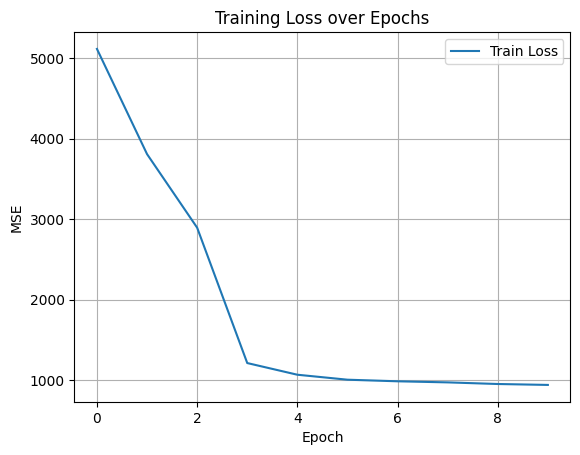

316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1365.5201
Test MSE: 1365.5201


In [12]:
# 학습 중 손실(MSE) 변화 시각화
plt.plot(history.history['loss'], label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.legend()
plt.show()

# 테스트셋에 대한 최종 성능 (MSE 기준)
test_loss = model.evaluate(X_test, y_test)
print(f"Test MSE: {test_loss:.4f}")


316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


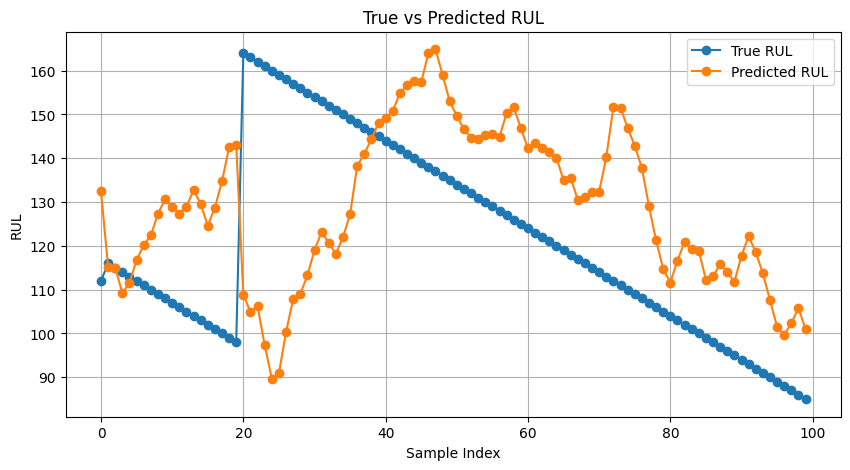

In [13]:
import matplotlib.pyplot as plt

# 예측 수행
y_pred = model.predict(X_test)

# 실제값과 예측값을 비교 시각화
plt.figure(figsize=(10, 5))
plt.plot(y_test[:100], label='True RUL', marker='o')  # 실제 RUL (앞 100개만 표시)
plt.plot(y_pred[:100], label='Predicted RUL', marker='o')  # 예측 RUL
plt.title('True vs Predicted RUL')
plt.xlabel('Sample Index')
plt.ylabel('RUL')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# 모델 전체 저장 (구글 드라이브 경로)
model.save('/content/drive/MyDrive/my_rul_lstm_model.keras')

# 센서 데이터 변환에 썼던 Scaler도 함께 저장해야 나중에 추론할 수 있습니다.
import joblib
joblib.dump(scaler, '/content/drive/MyDrive/my_scaler.pkl')

['/content/drive/MyDrive/my_scaler.pkl']

In [16]:
# 현재 정의된 딥러닝 모델 및 Scaler 변수 이름 자동으로 찾기
model_found = False
scaler_found = False

for name, val in list(globals().items()):
    if not name.startswith('_'):
        val_type = str(type(val)).lower()
        if 'keras' in val_type or 'tensorflow' in val_type or 'sequential' in val_type:
            print(f"✅ 찾은 모델 변수 이름: {name}")
            model_found = True
        elif 'scaler' in val_type:
            print(f"✅ 찾은 Scaler 변수 이름: {name}")
            scaler_found = True

if not model_found:
    print("❌ 메모리에서 모델을 찾지 못했습니다. 위쪽의 '모델 학습 코드 셀'을 먼저 실행(▶)해야 합니다.")

✅ 찾은 Scaler 변수 이름: scaler
✅ 찾은 모델 변수 이름: model
✅ 찾은 모델 변수 이름: history


In [17]:
# 1. 구글 드라이브 마운트 (승인 창이 뜨면 허용 클릭)
from google.colab import drive
drive.mount('/content/drive')

# 2. 모델 및 Scaler 저장
import joblib

model.save('/content/drive/MyDrive/my_rul_lstm_model.keras')
joblib.dump(scaler, '/content/drive/MyDrive/my_scaler.pkl')

print("🎉 구글 드라이브에 성공적으로 저장되었습니다!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🎉 구글 드라이브에 성공적으로 저장되었습니다!
